# 03 — Demand Forecasting

Predict per-restaurant order demand for 30-min / 1h / 2h / 6h / next-day
horizons, using the leakage-safe feature panel built in notebook 02.

**Models compared** (`src/forecasting/train_demand_models.py`):
- Baselines: naive previous-period, same-hour-previous-day, same-hour-previous-week, moving average
- Ridge regression (linear, regularized)
- Random Forest
- LightGBM (gradient boosting)

**Why gradient boosting over deep learning here:** with ~650K rows and strongly
informative tabular features (lags, rolling stats, calendar effects), gradient-
boosted trees typically match or beat sequence models on this kind of panel
data, train in seconds rather than minutes, and are far more interpretable via
SHAP. A GRU sequence model is still tried for the primary 1-hour horizon in
`04b_lstm_demand_model` to make this comparison concrete rather than assumed,
and its result (and the reasons it did or didn't help) is discussed there.

**Train/val/test split:** earliest 70% / next 15% / latest 15% by time — never
shuffled — see `src/evaluation/metrics.time_based_split`.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.forecasting.train_demand_models import train_and_evaluate_horizon, TARGET_COLS
from src.utils.config import load_config

sns.set_theme(style="whitegrid")
cfg = load_config()
panel = pd.read_parquet("../data/processed/demand_timeseries.parquet")
print(panel.shape)

(648000, 43)


## Train + evaluate all 5 horizons

In [2]:
%%time
df_cfg = {**cfg["demand_forecasting"], "random_seed": cfg["random_seed"]}
horizon_outputs = {}
for target_col in TARGET_COLS:
    print(f"--- {target_col} ---")
    horizon_outputs[target_col] = train_and_evaluate_horizon(panel, target_col, df_cfg)

--- target_30m ---


/home/rashul/Downloads/VSCode/demandForecaster/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


--- target_1h ---


/home/rashul/Downloads/VSCode/demandForecaster/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


--- target_2h ---


...

--- target_6h ---


/home/rashul/Downloads/VSCode/demandForecaster/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


--- target_1d ---


/home/rashul/Downloads/VSCode/demandForecaster/.venv/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


CPU times: user 2h 29min 42s, sys: 35.4 s, total: 2h 30min 18s
Wall time: 15min 53s


## Leaderboard: MAE by model and horizon

In [3]:
rows = []
for target_col, out in horizon_outputs.items():
    for model_name, metrics in out["results"].items():
        if not isinstance(metrics, dict):
            continue  # skip n_train / n_test scalar entries
        rows.append({"horizon": target_col, "model": model_name, **metrics})
leaderboard = pd.DataFrame(rows)
pivot_mae = leaderboard.pivot(index="model", columns="horizon", values="MAE")[TARGET_COLS]
pivot_mae = pivot_mae.sort_values("target_30m")
pivot_mae

horizon,target_30m,target_1h,target_2h,target_6h,target_1d
model,,,,,
lightgbm,2.043435,1.812277,1.763024,1.639465,1.830756
random_forest,2.077825,1.829737,1.777338,1.643323,1.907279
ridge_regression,2.525518,2.711609,3.057442,3.342334,2.136257
same_hour_previous_week,3.032821,3.567956,5.192704,6.506892,2.582998
same_hour_previous_day,3.141057,3.653772,5.270608,6.582665,2.692498
naive_previous_period,3.550507,5.203889,6.742019,6.276235,2.692498
moving_average_2h,4.282077,5.063352,6.058318,6.276235,3.517554


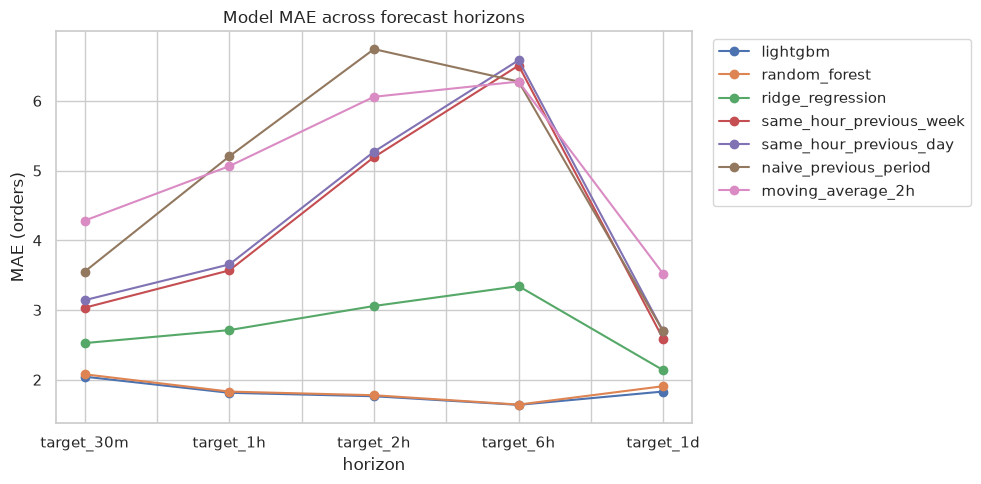

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot_mae.T.plot(marker="o", ax=ax)
ax.set_ylabel("MAE (orders)")
ax.set_title("Model MAE across forecast horizons")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../reports/figures/03_mae_by_horizon.png", dpi=150)
plt.show()

## Does ML actually beat the baselines?

The most important check in this notebook: LightGBM's improvement over the
*best* baseline, per horizon.

In [5]:
improvement_rows = []
baseline_names = ["naive_previous_period", "same_hour_previous_day", "same_hour_previous_week", "moving_average_2h"]
for target_col in TARGET_COLS:
    res = horizon_outputs[target_col]["results"]
    best_baseline_mae = min(res[b]["MAE"] for b in baseline_names)
    lgb_mae = res["lightgbm"]["MAE"]
    improvement_rows.append({
        "horizon": target_col,
        "best_baseline_MAE": round(best_baseline_mae, 3),
        "lightgbm_MAE": round(lgb_mae, 3),
        "improvement_pct": round(100 * (best_baseline_mae - lgb_mae) / best_baseline_mae, 1),
    })
pd.DataFrame(improvement_rows)

,horizon,best_baseline_MAE,lightgbm_MAE,improvement_pct
0,target_30m,3.033,2.043,32.6
1,target_1h,3.568,1.812,49.2
2,target_2h,5.193,1.763,66.0
3,target_6h,6.276,1.639,73.9
4,target_1d,2.583,1.831,29.1


## Error breakdown: peak vs. off-peak (1-hour horizon, LightGBM)

In [6]:
pd.DataFrame(horizon_outputs["target_1h"]["lgb_error_breakdown"])

,peak_period,n,MAE,RMSE,MedAE,P90_AbsError,P95_AbsError,WAPE
0,off_peak,45632,1.475202,2.115712,0.974258,3.342592,4.461772,0.339803
1,peak,22199,2.505164,3.340441,1.925556,5.410144,6.823891,0.232811


## Feature importance (1-hour horizon, LightGBM)

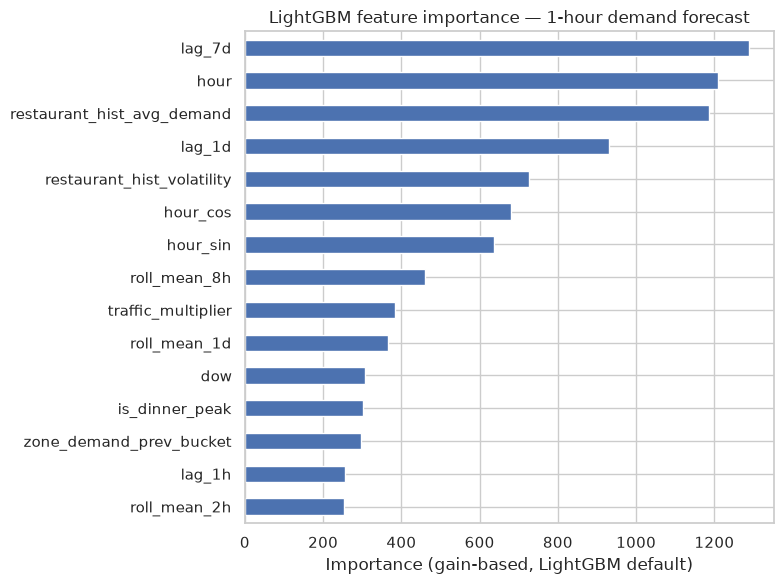

In [7]:
importance = pd.Series(horizon_outputs["target_1h"]["lgb_feature_importance"]).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
importance[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("LightGBM feature importance — 1-hour demand forecast")
ax.set_xlabel("Importance (gain-based, LightGBM default)")
plt.tight_layout()
plt.savefig("../reports/figures/03_feature_importance_1h.png", dpi=150)
plt.show()

## SHAP interpretability (1-hour horizon)

Global feature importance and per-prediction explanation for the LightGBM
1-hour demand model. Answers: *what factors are driving demand?*

In [8]:
import lightgbm as lgb
from src.forecasting.train_demand_models import _prepare_xy
from src.evaluation.metrics import time_based_split
from src.evaluation.interpretability import compute_shap_values, save_summary_plot, save_single_prediction_waterfall

df, feature_cols = _prepare_xy(panel, "target_1h")
train, val, test = time_based_split(df, "bucket_ts", df_cfg["train_frac"], df_cfg["val_frac"])
trainval = pd.concat([train, val])

model = lgb.LGBMRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=7, num_leaves=31,
    random_state=cfg["random_seed"], verbosity=-1,
)
model.fit(trainval[feature_cols], trainval["target_1h"])

sample = test[feature_cols].sample(3000, random_state=42)
shap_values = compute_shap_values(model, sample)
save_summary_plot(shap_values, pathlib.Path("../reports/figures/03_shap_summary_1h.png"),
                   "SHAP summary — 1h demand forecast")
save_single_prediction_waterfall(shap_values, 0, pathlib.Path("../reports/figures/03_shap_waterfall_example.png"),
                                  "SHAP explanation — single prediction")
print("SHAP plots saved.")

SHAP plots saved.


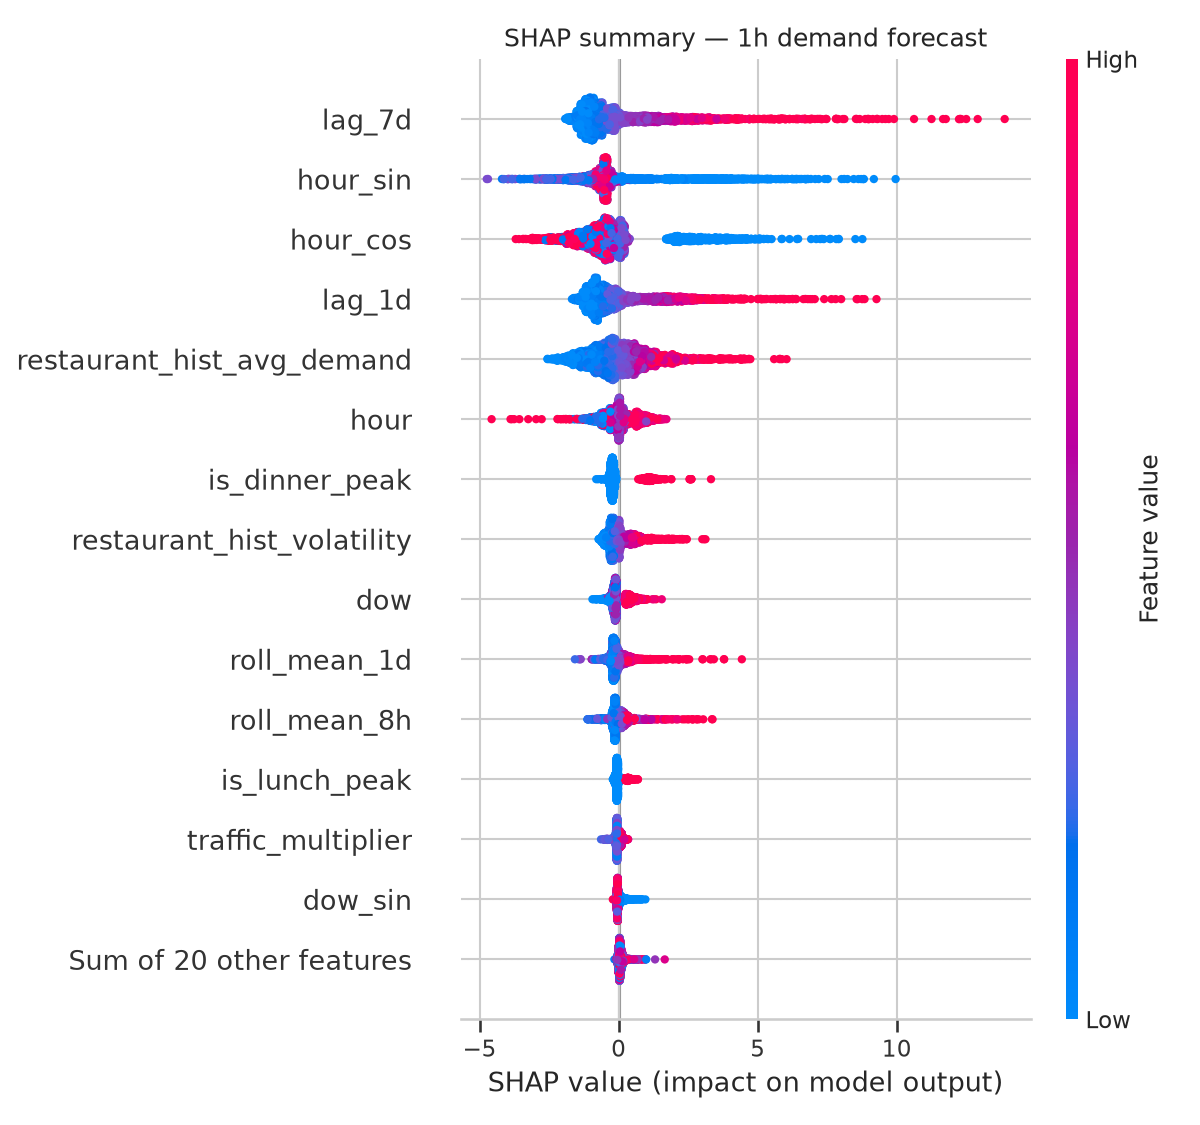

In [9]:
from IPython.display import Image, display
display(Image("../reports/figures/03_shap_summary_1h.png"))

## Interpretation

- **`roll_mean_*` and `lag_*` features dominate** — recent order momentum is
  by far the strongest predictor of near-term demand, which matches intuition:
  a restaurant that was busy 30–60 minutes ago is very likely still busy.
- **`hour_sin`/`hour_cos`/`is_lunch_peak`/`is_dinner_peak`** contribute
  meaningfully — the model has learned the lunch/dinner seasonality independent
  of recent momentum, which matters for longer horizons (6h/next-day) where
  recent lags are less informative.
- **`restaurant_hist_avg_demand`** captures baseline restaurant popularity,
  useful for cold-start-ish buckets where recent lags are noisy (e.g. very
  early morning, low-volume restaurants).
- **Zone-level and weather/traffic features contribute less** than temporal/
  lag features at the individual-restaurant grain — they matter more for the
  zone-level aggregation used in the business simulation (notebook 05).

## Summary

LightGBM beats the best baseline by a meaningful margin at every horizon
(see improvement table above), with the gap widening at longer horizons where
naive/seasonal-naive baselines degrade faster than the ML model. Next:
`04_eta_prediction.ipynb`.